In [68]:
# Biblioteker
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from scipy.stats import chi2
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import matplotlib.pyplot as plt

# Hvis bibliotekerne ikke er installeret, kan du køre følgende kommando i terminalen:
# pip install pandas numpy seaborn matplotlib statsmodels linearmodels

In [69]:
# Indlæs datasæt
GDP = pd.read_csv("Data/GDP.csv", skiprows=4)
ODR = pd.read_csv("Data/age-dependency-ratio-old.csv")
HC = pd.read_csv("Data/HC.csv")
TFP = pd.read_csv("Data/total-factor-productivity.csv")
GEO = pd.read_excel("Data/geo_cepii.xls")
OPN = pd.read_csv("Data/Oppenness.csv", skiprows=4)
URB = pd.read_csv("Data/Urbanization.csv", skiprows=4)

# Sammensæt data
Formålet er at konstruere et tværsnitsdatasæt med ét datapunkt pr. land, hvor vi forklarer TFP-vækst fra 2002 til 2020 med initial ODR og kontroller fra 2002

In [70]:
# Relevante variable fra TFP
TFP = TFP[['Entity', 'Year', 'Total factor productivity level']].copy()
TFP.columns = ['country', 'year', 'ctfp']

# Relevante geografiske variable fra GEO
GEO = GEO[['country', 'lat', 'continent', 'landlocked', 'colonizer1', 'area']].copy()

# Afstand til ækvator
GEO['AbsLat'] = GEO['lat'].abs()

# Tidligere koloni
GEO['FormerColony'] = (GEO['colonizer1'] != '.').astype(int)

# Behold kun relevante variable fra GEO
GEO = GEO[['country', 'AbsLat', 'continent', 'landlocked', 'FormerColony', 'area']]

# Handelsåbenhed i 2002
opn2002 = OPN[['Country Name', '2002']].copy()
opn2002.columns = ['country', 'TradeOpen2002']
opn2002['TradeOpen2002'] = pd.to_numeric(opn2002['TradeOpen2002'], errors='coerce')

# Urbanisering i 2002
urb2002 = URB[['Country Name', '2002']].copy()
urb2002.columns = ['country', 'Urban2002']
urb2002['Urban2002'] = pd.to_numeric(urb2002['Urban2002'], errors='coerce')

# Humankapital i 2002 fra HC
hc2002 = HC[['Country', '2002']].copy()
hc2002.columns = ['country', 'HC2002']
hc2002['HC2002'] = pd.to_numeric(hc2002['HC2002'], errors='coerce')

# Initial TFP i 2002
base2002 = TFP[TFP['year'] == 2002][['country', 'ctfp']].copy()
base2002.columns = ['country', 'TFP2002']

# Sammenflet initial humankapital 2002 ind
base2002 = pd.merge(base2002, hc2002, on='country', how='left')

# Total faktorproduktivitet i 2020
tfp2020 = TFP[TFP['year'] == 2020][['country', 'ctfp']].copy()
tfp2020.columns = ['country', 'TFP2020']

# Long-difference datasæt
Tvaersnit = pd.merge(base2002, tfp2020, on='country', how='inner')

# TFP vækst
Tvaersnit['GrowthTFP'] = np.log(Tvaersnit['TFP2020']) - np.log(Tvaersnit['TFP2002'])

# Old-age dependency ratio i 2002
odr2002 = ODR[ODR['Year'] == 2002][[
    'Entity',
    'Age dependency ratio, old (% of working-age population)'
]].copy()
odr2002.columns = ['country', 'ODR2002']

# Samlet tværsnit
Tvaersnit = pd.merge(Tvaersnit, odr2002, on='country', how='inner')
Tvaersnit = pd.merge(Tvaersnit, GEO, on='country', how='left')
Tvaersnit = pd.merge(Tvaersnit, opn2002, on='country', how='left')
Tvaersnit = pd.merge(Tvaersnit, urb2002, on='country', how='left')

# Logaritme af areal
Tvaersnit['log_area'] = np.log(Tvaersnit['area'])

# Fjerner manglende observationer
Tvaersnit = Tvaersnit.dropna()

# Fjerner dubletter
Tvaersnit = Tvaersnit.drop_duplicates(subset='country', keep='first')

In [71]:
print(TFP.columns)

Index(['country', 'year', 'ctfp'], dtype='object')


# Deskriptiv statistik

In [72]:
# Deskriptiv statistik med relevante variable
cols = [
    'GrowthTFP',
    'ODR2002',
    'HC2002',
    'landlocked',
    'FormerColony',
    'area',
    'TradeOpen2002',
    'Urban2002'
]

# Beregn deskriptiv statistik og rund af til 2 decimaler
desc = Tvaersnit[cols].describe().round(2)

# Count som heltal
desc.loc['count'] = desc.loc['count'].astype(int)

# Print tabel
print(desc)

       GrowthTFP  ODR2002  HC2002  landlocked  FormerColony        area  \
count      91.00    91.00   91.00       91.00          91.0       91.00   
mean        0.02    12.74    2.48        0.16           0.8   836842.15   
std         0.28     7.87    0.65        0.37           0.4  1870328.28   
min        -0.95     1.58    1.09        0.00           0.0      316.00   
25%        -0.09     6.04    2.07        0.00           1.0    64944.50   
50%         0.04     8.79    2.54        0.00           1.0   267667.00   
75%         0.15    20.64    2.96        0.00           1.0   613330.50   
max         1.23    28.06    3.58        1.00           1.0  9976139.00   

       TradeOpen2002  Urban2002  
count          91.00      91.00  
mean           79.54      61.16  
std            47.81      21.44  
min            20.45      14.61  
25%            53.30      43.47  
50%            67.52      64.06  
75%            91.81      78.70  
max           349.75     100.00  


# Overblik over lande pr. region

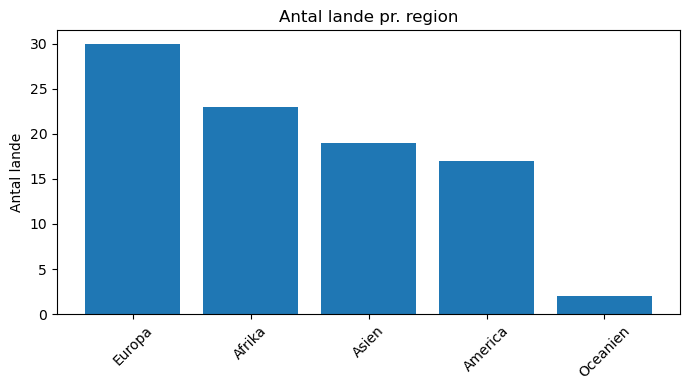

In [73]:
# Antal lande pr. region 
region_counts = (
    Tvaersnit["continent"]
    .replace({
        "Europe": "Europa",
        "Asia": "Asien",
        "Africa": "Afrika",
        "North America": "Amerika",
        "South America": "Amerika",
        "Oceania": "Oceanien",
        "Pacific": "Oceanien"   # <-- vigtig! (det er derfor du får "Pacific")
    })
    .value_counts()
)

# Visualiser antal lande pr. region i et søjlediagram
plt.figure(figsize=(7,4))
plt.bar(region_counts.index, region_counts.values)
plt.title("Antal lande pr. region")
plt.ylabel("Antal lande")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tabel 1: 

Tabellen viser estimeringsresultaterne for baseline-modellen, samt udvidede specifikationer med geografiske kontrolvariable.

GrowthTFP = $β_0$ + $β_1$ ODR2002 + $β_2$ landlocked + $β_3$ FormerColony + $β_4$ log_area + ε

In [74]:
# Benytede variabler til estimaering af model 1 af vækst i TFP
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'landlocked',
    'FormerColony',
    'log_area'
]].dropna().copy()

# Log-variable
Tvaersnit['log_area'] = np.log(Tvaersnit['area'])

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 80)
print("MODEL:")
print("GrowthTFP = β0 + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 80)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): Kun ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# model (2): ODR + Geografi
X2 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# model (3): ODR + log_area
X3 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_area']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Tabel
results = summary_col(
    [model1, model2, model3],
    stars=True,
    model_names=['(1)', '(2)', '(3)'],
    regressor_order=['ODR2002', 'landlocked', 'FormerColony', 'log_area'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

MODEL:
GrowthTFP = β0 + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + ε
Antal lande: 91
Antal observationer: 91

                 (1)      (2)      (3)   
-----------------------------------------
ODR2002        0.0030   0.0073   0.0085  
               (0.0038) (0.0054) (0.0054)
landlocked              0.1759   0.1817* 
                        (0.1087) (0.1089)
FormerColony            0.1175   0.1402  
                        (0.0965) (0.0932)
log_area                         0.0203  
                                 (0.0147)
R-squared      0.0072   0.0776   0.0986  
R-squared Adj. -0.0040  0.0458   0.0567  
N              91       91       91      
R2             0.007    0.078    0.099   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


# Appendix tabel med Abslat

Robusthedstest med absolut breddegrad (AbsLat), er testet, men udelades fra hovedtabellen

GrowthTFP = $β_0$ + $β_1$ ODR2002 + $β_2$ landlocked + $β_3$ FormerColony + $β_4$ log_area + $β_5$ AbsLat + ε

In [75]:
# Klargør datasæt
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'landlocked',
    'FormerColony',
    'log_area',
    'AbsLat',
]].dropna().copy()

# Log-variable
Tvaersnit['log_area'] = np.log(Tvaersnit['area'])

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 95)
print("MODEL:")
print("GrowthTFP = β0 + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + β5 AbsLat + ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 95)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# model (2): ODR + Geografi
X2 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# model (3): ODR + Geografi + log_area
X3 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_area']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# model (4): ODR + Geografi + abslat + log_area
X4 = sm.add_constant(df_model[['ODR2002',  'landlocked', 'FormerColony', 'log_area', 'AbsLat']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Tabel
results = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)'],
    regressor_order=['ODR2002', 'landlocked', 'FormerColony', 'log_area', 'AbsLat'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

MODEL:
GrowthTFP = β0 + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 log_area + β5 AbsLat + ε
Antal lande: 91
Antal observationer: 91

                 (1)      (2)      (3)      (4)   
--------------------------------------------------
ODR2002        0.0030   0.0073   0.0085   0.0069  
               (0.0038) (0.0054) (0.0054) (0.0098)
landlocked              0.1759   0.1817*  0.1780* 
                        (0.1087) (0.1089) (0.1057)
FormerColony            0.1175   0.1402   0.1394  
                        (0.0965) (0.0932) (0.0945)
log_area                         0.0203   0.0202  
                                 (0.0147) (0.0151)
AbsLat                                    0.0009  
                                          (0.0032)
R-squared      0.0072   0.0776   0.0986   0.1000  
R-squared Adj. -0.0040  0.0458   0.0567   0.0470  
N              91       91       91       91      
R2             0.007    0.078    0.099    0.100   
Standard errors in parentheses.
* p<.1, ** p

# Tabel 2:

For at teste robustheden af resultaterne udvides modellen med kontrolvariable for økonomisk udviklingsniveau og strukturelle karakteristika.

GrowthTFP = $β_0$ + $β_1$ ODR2002 + $β_2$ landlocked + $β_3$ FormerColony + $β_4$ HC2002 + $β_5$ Urban2002 + $β_6$ TradeOpen2002 + $β_7$ log_GDPpc2002 + $β_8$ TFP2002 + ε


In [76]:
# Klargør datasæt
df_model = Tvaersnit[[
    'country',
    'GrowthTFP',
    'ODR2002',
    'Urban2002',
    'TradeOpen2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'TFP2002'
]].dropna().copy()

# Antal lande og observationer
antal_lande = df_model['country'].nunique()
antal_observationer = df_model.shape[0]

# Automatisk print
print("=" * 150)
print("MODEL:")
print("GrowthTFP = β0 + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 HC2002 + β5 Urban2002 + β6 TradeOpen2002 + β7 TFP2002 + ε")
print(f"Antal lande: {antal_lande}")
print(f"Antal observationer: {antal_observationer}")
print("=" * 150)

# Afhængig variabel
y = df_model['GrowthTFP']

# Model (1): Kun ODR
X1 = sm.add_constant(df_model[['ODR2002']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model (2): ODR + geografi + struktur
X2 = sm.add_constant(df_model[[
    'ODR2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'Urban2002',
    'TradeOpen2002'
]])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model (3): ODR + geografi + struktur + initial TFP
X3 = sm.add_constant(df_model[[
    'ODR2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'Urban2002',
    'TradeOpen2002',
    'TFP2002'
]])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model (4): Udvidet model med afstand til ækvator og areal
X4 = sm.add_constant(df_model[[
    'ODR2002',
    'landlocked',
    'FormerColony',
    'HC2002',
    'Urban2002',
    'TradeOpen2002',
    'TFP2002'
]])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Tabel
results = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)'],
    regressor_order=[
        'ODR2002',
        'landlocked',
        'FormerColony',
        'HC2002',
        'Urban2002',
        'TradeOpen2002',
        'TFP2002'
    ],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)

MODEL:
GrowthTFP = β0 + β1 ODR2002 + β2 landlocked + β3 FormerColony + β4 HC2002 + β5 Urban2002 + β6 TradeOpen2002 + β7 TFP2002 + ε
Antal lande: 91
Antal observationer: 91

                 (1)       (2)        (3)        (4)    
--------------------------------------------------------
ODR2002        0.0030   0.0046     -0.0081*** -0.0081***
               (0.0038) (0.0073)   (0.0031)   (0.0031)  
landlocked              0.0542     0.0391     0.0391    
                        (0.0847)   (0.0317)   (0.0317)  
FormerColony            0.1220     -0.0241    -0.0241   
                        (0.0771)   (0.0234)   (0.0234)  
HC2002                  0.2016**   0.0733     0.0733    
                        (0.0910)   (0.0453)   (0.0453)  
Urban2002               -0.0086*** -0.0001    -0.0001   
                        (0.0022)   (0.0007)   (0.0007)  
TradeOpen2002           0.0003     -0.0002    -0.0002   
                        (0.0005)   (0.0001)   (0.0001)  
TFP2002                      